# Split Train / Val / Test — PAD-UFES-20
**Estrategia:** Partición estratificada 80/10/10 por clase diagnóstica (6 clases)  
**Objetivo:** Preservar la distribución de clases en los 3 subconjuntos, incluyendo MEL (n=52)

metadata_imputed.csv

       ↓
  binarizar (label 0/1)
      
       ↓

  split estratificado por 'diagnostic' (6 clases)
       
       ↓

split_train.csv  ← tiene columna 'label' incluida

split_val.csv    ← tiene columna 'label' incluida  

split_test.csv   ← tiene columna 'label' incluida

Estratificamos por diagnostic (6 clases) en vez de por label (2 clases) precisamente para que MEL no desaparezca en algún split. Pero el label binario viaja junto en el CSV y es lo que usan los experimentos para entrenar y evaluar.

## 0. Montar Drive y cargar datos

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

BASE_PATH = '/content/drive/MyDrive/PFC1 - Noemi/dataset/PAD-UFES-20'
CSV_PATH  = os.path.join(BASE_PATH, 'metadata_imputed.csv')

df = pd.read_csv(CSV_PATH)

# Binarizar etiquetas
MALIGNANT   = {'BCC', 'MEL', 'SCC'}
df['label'] = df['diagnostic'].apply(lambda x: 1 if x in MALIGNANT else 0)

# Construir índice de imágenes
IMGS_DIR = os.path.join(BASE_PATH, 'images')
img_index = {}
for part in ['imgs_part_1', 'imgs_part_2', 'imgs_part_3']:
    part_path = os.path.join(IMGS_DIR, part)
    for fname in os.listdir(part_path):
        img_index[fname] = os.path.join(part_path, fname)
df['img_path'] = df['img_id'].map(img_index)

print(f'Dataset cargado: {len(df)} muestras')
print(f'Clases: {df["diagnostic"].value_counts().to_dict()}')

Dataset cargado: 2298 muestras
Clases: {'BCC': 845, 'ACK': 730, 'NEV': 244, 'SEK': 235, 'SCC': 192, 'MEL': 52}


In [4]:
# Guardar label en el CSV para no tener que binarizar en cada notebook
df.drop(columns=['img_path']).to_csv(CSV_PATH, index=False)
print(f'metadata_imputed.csv actualizado con columna label')
print(df['label'].value_counts())

metadata_imputed.csv actualizado con columna label
label
0    1209
1    1089
Name: count, dtype: int64


## 1. Split estratificado 80 / 10 / 10

In [5]:
# Split estratificado por clase diagnóstica (6 clases, no binario)
# Así garantizamos que MEL (n=52) quede representado en los 3 subsets

# Paso 1: separar train (80%) del resto (20%)
df_train, df_temp = train_test_split(
    df,
    test_size=0.20,
    stratify=df['diagnostic'],
    random_state=42
)

# Paso 2: dividir el 20% restante en val (10%) y test (10%)
df_val, df_test = train_test_split(
    df_temp,
    test_size=0.50,
    stratify=df_temp['diagnostic'],
    random_state=42
)

print(f'Train : {len(df_train)} muestras ({len(df_train)/len(df)*100:.1f}%)')
print(f'Val   : {len(df_val)} muestras ({len(df_val)/len(df)*100:.1f}%)')
print(f'Test  : {len(df_test)} muestras ({len(df_test)/len(df)*100:.1f}%)')

Train : 1838 muestras (80.0%)
Val   : 230 muestras (10.0%)
Test  : 230 muestras (10.0%)


## 2. Verificar distribución por clase en cada split

In [6]:
# Tabla de distribución por clase
splits = {'Train': df_train, 'Val': df_val, 'Test': df_test}
classes = ['BCC', 'ACK', 'NEV', 'SEK', 'SCC', 'MEL']

rows = []
for cls in classes:
    row = {'Clase': cls, 'Tipo': 'Maligno' if cls in MALIGNANT else 'Benigno'}
    for split_name, split_df in splits.items():
        n   = (split_df['diagnostic'] == cls).sum()
        pct = n / (split_df['diagnostic'] == cls).sum() * 100 if n > 0 else 0
        row[f'{split_name} (n)'] = n
        row[f'{split_name} (%)'] = f'{n/len(df)*100:.1f}%'
    row['Total'] = (df['diagnostic'] == cls).sum()
    rows.append(row)

dist_df = pd.DataFrame(rows)
print('Distribución por clase en cada split:')
print(dist_df.to_string(index=False))

Distribución por clase en cada split:
Clase    Tipo  Train (n) Train (%)  Val (n) Val (%)  Test (n) Test (%)  Total
  BCC Maligno        676     29.4%       84    3.7%        85     3.7%    845
  ACK Benigno        584     25.4%       73    3.2%        73     3.2%    730
  NEV Benigno        195      8.5%       25    1.1%        24     1.0%    244
  SEK Benigno        188      8.2%       24    1.0%        23     1.0%    235
  SCC Maligno        153      6.7%       19    0.8%        20     0.9%    192
  MEL Maligno         42      1.8%        5    0.2%         5     0.2%     52


In [7]:
# Verificar ratio maligno/benigno en cada split
print('\nRatio binario por split:')
for split_name, split_df in splits.items():
    mal = split_df['label'].sum()
    ben = len(split_df) - mal
    print(f'  {split_name:6s} — Maligno: {mal} ({mal/len(split_df)*100:.1f}%) | Benigno: {ben} ({ben/len(split_df)*100:.1f}%)')


Ratio binario por split:
  Train  — Maligno: 871 (47.4%) | Benigno: 967 (52.6%)
  Val    — Maligno: 108 (47.0%) | Benigno: 122 (53.0%)
  Test   — Maligno: 110 (47.8%) | Benigno: 120 (52.2%)


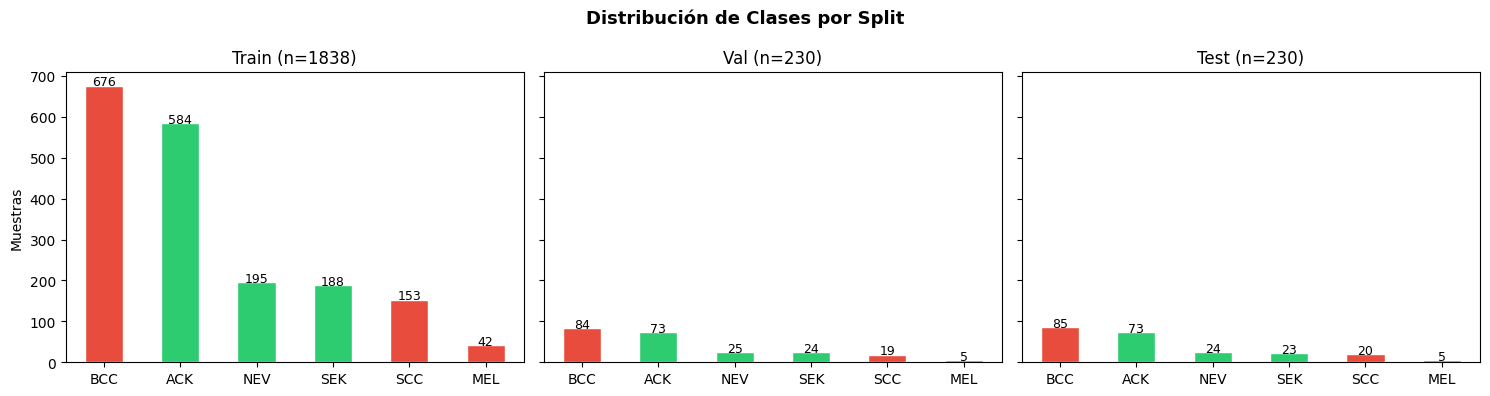

Guardado: split_distribucion.png


In [9]:
# Visualización
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
fig.suptitle('Distribución de Clases por Split', fontsize=13, fontweight='bold')

for ax, (split_name, split_df) in zip(axes, splits.items()):
    vc     = split_df['diagnostic'].value_counts().reindex(classes)
    colors = ['#e74c3c' if c in MALIGNANT else '#2ecc71' for c in classes]
    vc.plot(kind='bar', ax=ax, color=colors, edgecolor='white')
    ax.set_title(f'{split_name} (n={len(split_df)})')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=0)
    for bar, val in zip(ax.patches, vc):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                str(int(val)), ha='center', fontsize=9)

axes[0].set_ylabel('Muestras')
plt.tight_layout()
plt.savefig(os.path.join(BASE_PATH, 'split_distribucion.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: split_distribucion.png')

## 3. Guardar los splits

In [10]:
# Guardar CSVs de cada split (sin img_path, esa la reconstruimos en cada experimento)
df_train.drop(columns=['img_path']).to_csv(os.path.join(BASE_PATH, 'split_train.csv'), index=False)
df_val.drop(columns=['img_path']).to_csv(os.path.join(BASE_PATH, 'split_val.csv'),   index=False)
df_test.drop(columns=['img_path']).to_csv(os.path.join(BASE_PATH, 'split_test.csv'),  index=False)

print('Splits guardados en Drive:')
print(f'   split_train.csv — {len(df_train)} filas')
print(f'   split_val.csv   — {len(df_val)} filas')
print(f'   split_test.csv  — {len(df_test)} filas')

Splits guardados en Drive:
   split_train.csv — 1838 filas
   split_val.csv   — 230 filas
   split_test.csv  — 230 filas
